<a href="https://colab.research.google.com/github/ldaniel-hm/eml_tabular/blob/main/MonteCarlo_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monte Carlo On-Policy y Off-Policy en Taxi-v3**

_Estudio comparativo de control Monte Carlo tabular con muestreo por importancia ponderado_

Este notebook implementa y compara dos algoritmos de control Monte Carlo sobre el entorno **Taxi-v3** de Gymnasium:

- **On-Policy (Algoritmo 3, todas las visitas):** la política de exploración coincide con la que se mejora (ε-greedy). La actualización de Q se realiza con el retorno del episodio actual, sin corrección de importancia.
- **Off-Policy (Algoritmo 6, IS ponderado):** dos políticas distintas — política de comportamiento $b$ (ε-greedy) para generar datos y política objetivo $\pi$ (greedy pura) que se mejora. El ratio de importancia $W = \pi(A_t|S_t)/b(A_t|S_t)$ escala cada retorno; el bucle de retropropagación se interrumpe en cuanto se toma una acción no-greedy (porque $\pi(a|s)=0$ y $W=0$).

### ¿Por qué Taxi-v3?

FrozenLake ofrece recompensas binarias (0 ó 1). Taxi-v3 introduce una estructura más rica:

- **500 estados discretos**: 25 posiciones del taxi × 5 ubicaciones del pasajero × 4 destinos.
- **6 acciones**: South(0), North(1), East(2), West(3), Pickup(4), Dropoff(5).
- **Recompensas**: −1 por paso, +20 entrega exitosa, −10 acción ilegal (pickup/dropoff en posición incorrecta).
- **Señal de recompensa escasa y ruidosa**: las acciones Pickup/Dropoff son determinantes pero tienen alta penalización si se ejecutan incorrectamente.

Este entorno permite estudiar cómo on-policy y off-policy difieren cuando hay acciones con consecuencias asimétricas y la política de exploración genera experiencias alejadas de la política objetivo.

## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de dependencias**: librería `gymnasium`.
- **Importación de librerías**: `numpy`, `matplotlib`, `tqdm`.
- **Creación del entorno Taxi-v3**: espacio de observación `Discrete(500)`, espacio de acciones `Discrete(6)`, `render_mode='ansi'` para visualización en texto.

##### _________ **Código de la Instalación e Importación**
----

In [16]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium

In [17]:
#@title Importamos librerias
import sys
sys.path.insert(0, 'src')

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

from agents import MonteCarloOnPolicyAgent, MonteCarloOffPolicyAgent
from plotting import plot, plot_lengths, show_greedy_episode, print_q_summary

In [18]:
# @title Semilla para reproducibilidad (sección 5.4 del PDF)
# Patrón recomendado: fijar la misma semilla en NumPy, Python y Gymnasium.
# Sin PyTorch porque este notebook es tabular (no usa redes neuronales).
SEED = 2024

# Fijar la semilla en NumPy
np.random.seed(SEED)
np.random.default_rng(SEED)

# Fijar la semilla en Python (evita variabilidad en hashing)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Semilla fija: SEED = {SEED}")

Semilla fija: SEED = 2024


In [19]:
#@title Importamos el entorno Taxi-v3
env = gym.make('Taxi-v3', render_mode='ansi')
env.reset(seed=SEED)   # Fija la semilla del entorno (patrón sección 5.4 del PDF)

nS = env.observation_space.n  # 500
nA = env.action_space.n       # 6
print(f"Estados: {nS}, Acciones: {nA}")
print(f"Recompensas: -1 por paso | +20 entrega exitosa | -10 acción ilegal")
print()
# Estado inicial de ejemplo
obs, info = env.reset(seed=SEED)
print(f"Estado inicial (seed={SEED}): {obs}")
taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(obs)
locs = ['R', 'G', 'Y', 'B', 'en taxi']
print(f"  Taxi: ({taxi_row},{taxi_col}), Pasajero: {locs[pass_loc]}, Destino: {locs[dest_idx]}")
print(env.render())

Estados: 500, Acciones: 6
Recompensas: -1 por paso | +20 entrega exitosa | -10 acción ilegal

Estado inicial (seed=2024): 333
  Taxi: (3,1), Pasajero: B, Destino: G
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




## **2. Diseño del Agente**

El diseño del agente sigue el esquema de Gymnasium (sección 5.2): `__init__`, `get_action`, `update`, `stats`.

### Políticas
- **ε-soft** (`random_epsilon_greedy_policy`): distribución base con $\pi(a|s) \geq \varepsilon/|A|$ para todas las acciones.
- **ε-greedy** (`epsilon_greedy_policy`): muestrea desde la ε-soft. Usada por la política de comportamiento $b$.

### Agentes
- **`MonteCarloOnPolicyAgent`**: actualiza Q con retornos calculados hacia atrás al final del episodio (todas las visitas). Media incremental: $Q(s,a) \leftarrow Q(s,a) + \frac{1}{n(s,a)}[G - Q(s,a)]$.
- **`MonteCarloOffPolicyAgent`**: aplica el Algoritmo 6 de Sutton & Barto. Bucle inverso que acumula $C(s,a) \mathrel{+}= W$ y actualiza $Q(s,a) \mathrel{+}= \frac{W}{C(s,a)}[G - Q(s,a)]$; se interrumpe cuando $A_t \neq \arg\max Q[s]$.

Ambos agentes comparten la misma función `train()` con el bucle episódico estándar.

#### **Código de las políticas y algoritmos MC**
----------------

In [20]:
# @title Constantes del entorno Taxi-v3
# Acciones del entorno Taxi-v3
SOUTH, NORTH, EAST, WEST, PICKUP, DROPOFF = 0, 1, 2, 3, 4, 5
ACTION_NAMES = {0: 'S↓', 1: 'N↑', 2: 'E→', 3: 'W←', 4: 'PU', 5: 'DO'}
# La política greedy se obtiene con agent.pi_star(seed=SEED, action_names=ACTION_NAMES)

In [21]:
# @title Agente Monte Carlo On-Policy — importado de agents/monte_carlo_on_policy_agent.py
# MonteCarloOnPolicyAgent implementa el Algoritmo 3 de Sutton & Barto (2018):
#   - todas las visitas, retornos hacia atrás, media incremental
#   - política epsilon-greedy heredada de GymnasiumAgent
#   - decay opcional: epsilon = min(1.0, 1000/(t+1))
#   - método train(num_episodes) con bucle episódico estándar (sección 5.2)
#   - método stats() devuelve (list_stats, list_lengths)
#   - atributo q_values: tabla Q aprendida (nS × nA)

In [22]:
# @title Agente Monte Carlo Off-Policy — importado de agents/monte_carlo_off_policy_agent.py
# MonteCarloOffPolicyAgent implementa el Algoritmo 6 de Sutton & Barto (2018):
#   - política de comportamiento b: epsilon-greedy (genera episodios)
#   - política objetivo pi: greedy pura (la que se mejora)
#   - bucle backward con break cuando acción != argmax Q[s]
#   - acumulador C(s,a) para IS ponderado
#   - q_init opcional: inicialización aleatoria en [0, q_init]
#   - método train(num_episodes), stats(), pi_star()

## **3. Experimentación**

### **3.1 Representaciones Gráficas**

**Gráfica 1 — Recompensa media por episodio:** $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$

En Taxi-v3, la recompensa por episodio va de muy negativa (agente aleatorio con acciones ilegales frecuentes, $\approx -200$) hasta positiva ($\approx +6$ para el recorrido óptimo, que tarda ~14 pasos). Esta curva mide directamente la calidad de la política aprendida.

---

**Gráfica 2 — Longitud de los episodios:** $f(t) = \text{len}(\text{episodio}_t)$

Se pueden observar las mismas 3 fases que en FrozenLake, pero con dinámicas específicas de Taxi:

1. **Inicio:** el agente actúa aleatoriamente. Frecuentes penalizaciones de −10 por Pickup/Dropoff ilegales; los episodios se truncan a 200 pasos sin entregar al pasajero. La media móvil parte de 200 pasos.

2. **Aprendizaje:** el agente aprende a evitar penalizaciones y a orientarse hacia el pasajero y el destino. Los episodios empiezan a terminar con entrega exitosa, reduciendo la longitud. La media móvil desciende.

3. **Convergencia:** los episodios exitosos se estabilizan en la longitud óptima (~14–16 pasos para la configuración promedio de Taxi). La media móvil se aplana cerca del óptimo.

---

**Función `show_greedy_episode`:** ejecuta un episodio con la política greedy ($\arg\max_a Q(s,a)$) desde un estado fijo (semilla 42) y muestra el estado inicial y final en formato ANSI. Permite verificar visualmente si el taxi ha aprendido a recoger y entregar al pasajero.

In [23]:
# @title Funciones de visualización — todas importadas de plotting/plotting.py
# plot(list_stats, title, ylabel)            → recompensa media por episodio
# plot_lengths(list_lengths, window)         → longitud de episodios con media móvil
# show_greedy_episode(env, Q, max_steps, seed, title) → episodio ANSI con stats
# print_q_summary(env, Q, title)            → estadísticas de la tabla Q (Taxi-v3)
#
# La política greedy se obtiene con: agent.pi_star(seed, max_steps, action_names)
# definido en agents/gymnasium_agent.py

### **3.2 On-Policy en Taxi-v3**

Se entrenan **100 000 episodios** con $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\ 1000/(t+1))$.

El decaimiento es necesario porque:
- Al inicio, $\varepsilon$ alto favorece exploración amplia (el taxi aprende a evitar penalizaciones).
- Al final, $\varepsilon \to 0$ hace que la política de comportamiento se acerque a la greedy y los episodios sean más cortos y eficientes.

La semilla numpy fija (`np.random.seed(42)`) garantiza reproducibilidad.

In [24]:
# @title Aprendizaje on-policy
agent_on = MonteCarloOnPolicyAgent(env, epsilon=0.2, decay=True, discount_factor=1.0)
agent_on.train(num_episodes=100000)
list_stats_on, list_lengths_on = agent_on.stats()
Q_on = agent_on.q_values

 10%|█         | 10018/100000 [01:01<08:26, 177.60it/s]

success: -331.4665, epsilon: 0.1000


 20%|██        | 20030/100000 [01:58<08:02, 165.61it/s]

success: -249.2945, epsilon: 0.0500


 30%|███       | 30027/100000 [02:54<06:22, 182.71it/s]

...

success: -163.7058, epsilon: 0.0125


 90%|█████████ | 90025/100000 [08:22<00:49, 201.46it/s]

success: -159.7369, epsilon: 0.0111


100%|██████████| 100000/100000 [09:15<00:00, 179.86it/s]

success: -156.1384, epsilon: 0.0100


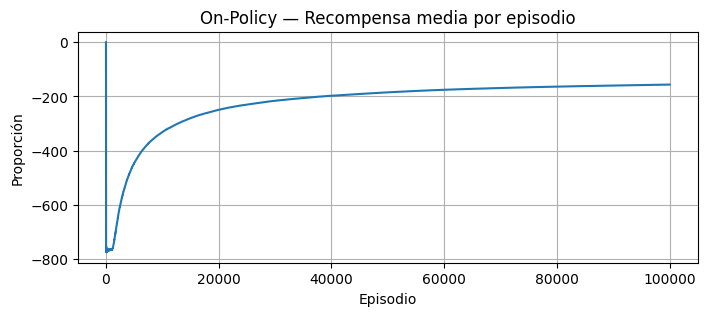

Recompensa media final: -156.14


In [25]:
#@title Recompensa media por episodio (on-policy)
plot(list_stats_on, title='On-Policy — Recompensa media por episodio')
print(f'Recompensa media final: {list_stats_on[-1]:.2f}')

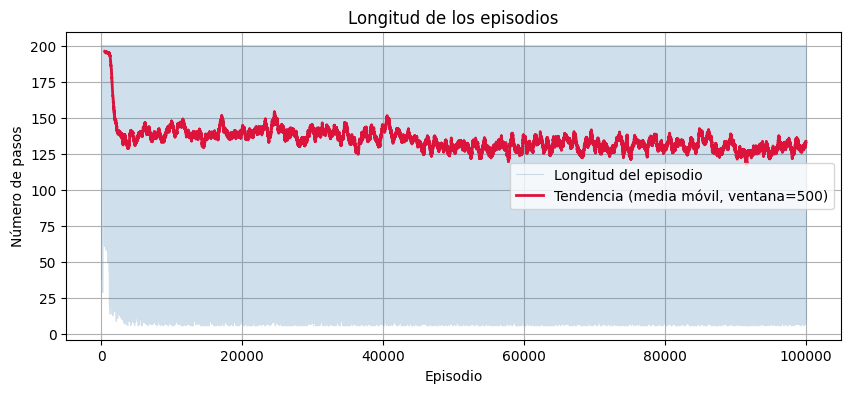

Longitud media final (últimos 1000 episodios): 131.85 pasos


In [26]:
#@title Longitud de episodios (on-policy)
plot_lengths(list_lengths_on)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths_on[-1000:]):.2f} pasos')

####.
Resumen estadístico de la tabla Q aprendida. Con 500 estados y 6 acciones la tabla tiene 3000 entradas.
Se muestran estadísticas globales y algunos estados decodificados para verificar que el agente ha aprendido acciones coherentes.

In [27]:
# @title Resumen tabla Q — on-policy
print_q_summary(env, Q_on, title="On-Policy — Tabla Q")

--- On-Policy — Tabla Q ---
  Entradas no nulas : 2400/3000 (80.0%)
  Max Q             : 20.000
  Min Q (no nulo)   : -483.228
  Q media (no nulo) : -242.007

  Muestra de estados:
  [  0] taxi=(0,0) pas=R       dst=R  -> mejor=S Q=[0. 0. 0. 0. 0. 0.]
  [124] taxi=(1,1) pas=G       dst=R  -> mejor=E Q=[-168.97 -158.03 -109.95 -168.19 -172.57 -172.46]
  [249] taxi=(2,2) pas=Y       dst=G  -> mejor=W Q=[-368.37 -407.38 -380.63 -181.44 -379.68 -404.54]
  [374] taxi=(3,3) pas=B       dst=Y  -> mejor=S Q=[ -89.97 -339.18 -350.21 -342.77 -330.49 -329.06]
  [499] taxi=(4,4) pas=en taxi dst=B  -> mejor=W Q=[-66.45 -71.   -50.34  17.71 -80.36 -90.28]


####.
Se muestra la política óptima greedy obtenida. `agent.pi_star(seed, action_names)` sigue `argmax Q[s]` desde el
estado inicial fijo (semilla SEED) y devuelve la secuencia de acciones en formato legible
(S↓ N↑ E→ W← PU DO). También se ejecuta `show_greedy_episode` para verificar visualmente
el resultado en formato ANSI.

In [28]:
# @title Política final (on-policy)
pi, actions = agent_on.pi_star(seed=SEED, action_names=ACTION_NAMES)
print("Política óptima obtenida (on-policy)")
print(f"Acciones: {actions}")
print()
show_greedy_episode(env, Q_on, seed=SEED, title="On-Policy — Episodio greedy")

Política óptima obtenida (on-policy)
Acciones: E→ → N↑ → E→ → S↓ → E→ → S↓ → W← → PU → E→ → N↑ → N↑ → W← → N↑ → N↑ → E→ → DO

On-Policy — Episodio greedy  |  Recompensa: 5  |  Pasos: 16  |  Éxito

Estado inicial:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Estado final:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



### **3.3 Off-Policy en Taxi-v3**

Se entrenan **100 000 episodios** con $\varepsilon$ con decaimiento.

Diferencias respecto al caso on-policy:

- **Bucle de retropropagación interrumpido**: solo la **cola greedy** final de cada episodio actualiza Q. En las primeras etapas, con $\varepsilon$ alto, casi todos los pasos son no-greedy (especialmente PICKUP y DROPOFF, que son raramente la acción greedy al inicio). Esto ralentiza el aprendizaje inicial.
- **Sin `q_init`**: Taxi-v3 inicializa los episodios desde estados aleatorios (300 configuraciones válidas), por lo que el sesgo de `argmax` hacia la primera acción no es sistemático como en FrozenLake 8×8.
- **Acciones ilegales y off-policy**: la penalización de −10 por PICKUP/DROPOFF ilegales genera retornos muy negativos para ciertos pares (s,a). Con IS ponderado, estos retornos solo actualizan Q cuando la acción ilegal coincide con la greedy, reduciendo la contaminación de la tabla Q.

In [29]:
# @title Aprendizaje off-policy
agent_off = MonteCarloOffPolicyAgent(env, epsilon=0.3, decay=True, discount_factor=1.0)
agent_off.train(num_episodes=100000)
list_stats_off, list_lengths_off = agent_off.stats()
Q_off = agent_off.q_values

 10%|█         | 10125/100000 [00:50<02:16, 656.42it/s]

success: -283.8957, epsilon: 0.1000


 20%|██        | 20240/100000 [01:02<01:02, 1284.02it/s]

success: -145.9676, epsilon: 0.0500


 30%|███       | 30201/100000 [01:10<00:53, 1305.02it/s]

...

success: -32.5580, epsilon: 0.0125


 90%|█████████ | 90184/100000 [01:54<00:06, 1418.55it/s]

success: -28.2182, epsilon: 0.0111


100%|██████████| 100000/100000 [02:01<00:00, 820.75it/s]

success: -24.7389, epsilon: 0.0100


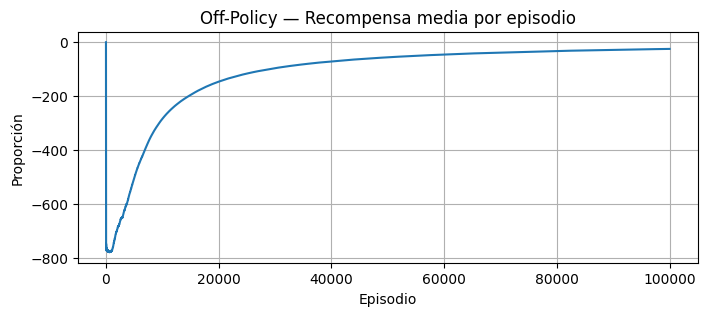

Recompensa media final: -24.74


In [30]:
#@title Recompensa media por episodio (off-policy)
plot(list_stats_off, title='Off-Policy — Recompensa media por episodio')
print(f'Recompensa media final: {list_stats_off[-1]:.2f}')

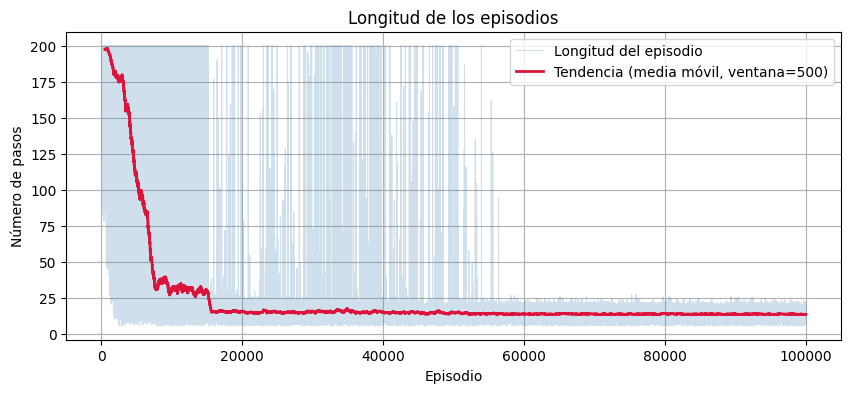

Longitud media final (últimos 1000 episodios): 13.97 pasos


In [31]:
#@title Longitud de episodios (off-policy)
plot_lengths(list_lengths_off)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths_off[-1000:]):.2f} pasos')

####.
Resumen estadístico de la tabla Q aprendida por el agente off-policy.
Se espera una cobertura menor de entradas no nulas respecto al on-policy, ya que el bucle de
retropropagación solo actualiza la cola greedy de cada episodio.

In [32]:
# @title Resumen tabla Q — off-policy
print_q_summary(env, Q_off, title="Off-Policy — Tabla Q")

--- Off-Policy — Tabla Q ---
  Entradas no nulas : 2328/3000 (77.6%)
  Max Q             : 20.000
  Min Q (no nulo)   : -12.259
  Q media (no nulo) : 3.120

  Muestra de estados:
  [  0] taxi=(0,0) pas=R       dst=R  -> mejor=S Q=[0. 0. 0. 0. 0. 0.]
  [124] taxi=(1,1) pas=G       dst=R  -> mejor=S Q=[  4.84  -0.45  -2.04   0.78 -10.   -10.56]
  [249] taxi=(2,2) pas=Y       dst=G  -> mejor=W Q=[ 3.08  4.75  2.85  6.98 -3.18 -3.98]
  [374] taxi=(3,3) pas=B       dst=Y  -> mejor=S Q=[10.35  3.33  6.38  7.87 -0.91 -0.56]
  [499] taxi=(4,4) pas=en taxi dst=B  -> mejor=W Q=[18. 17. 18. 19.  9.  9.]


In [33]:
# @title Política final (off-policy)
pi, actions = agent_off.pi_star(seed=SEED, action_names=ACTION_NAMES)
print("Política óptima obtenida (off-policy)")
print(f"Acciones: {actions}")
print()
show_greedy_episode(env, Q_off, seed=SEED, title="Off-Policy — Episodio greedy")

Política óptima obtenida (off-policy)
Acciones: E→ → N↑ → E→ → S↓ → S↓ → PU → N↑ → E→ → N↑ → N↑ → N↑ → DO

Off-Policy — Episodio greedy  |  Recompensa: 9  |  Pasos: 12  |  Éxito

Estado inicial:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Estado final:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)



### **3.4 Comparativa On-Policy vs Off-Policy**

Se representan en los mismos ejes las curvas de recompensa media y de longitud de episodios (media móvil) de ambos agentes. El objetivo es responder a las siguientes hipótesis:

1. **¿Cuál converge antes a recompensa positiva?** On-policy actualiza todos los estados visitados en cada episodio; off-policy solo la cola greedy. Se espera que on-policy sea más rápido en las primeras etapas.

2. **¿La política final es equivalente?** Si ambos convergen a $Q^*$, las curvas deberían cruzarse y estabilizarse en el mismo nivel. Una brecha persistente indicaría que el IS ponderado introduce sesgo o varianza adicional en Taxi.

3. **¿Difieren en la longitud del episodio convergido?** Una longitud menor en el off-policy indicaría que la política objetivo greedy es más eficiente (al no estar contaminada por la exploración ε-greedy).

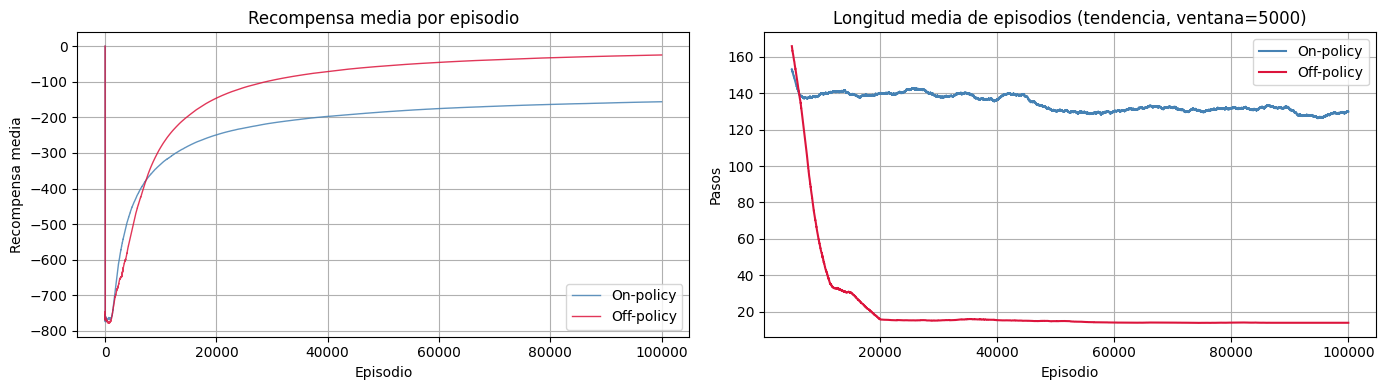

On-policy  — Recompensa media final: -156.14  | Longitud media final: 131.9 pasos  | epsilon final: 0.0100
Off-policy — Recompensa media final: -24.74  | Longitud media final: 14.0 pasos  | epsilon final: 0.0100


In [34]:
# @title Comparativa on-policy vs off-policy
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# --- Recompensa media ---
axes[0].plot(list_stats_on,  alpha=0.85, color='steelblue', linewidth=1, label='On-policy')
axes[0].plot(list_stats_off, alpha=0.85, color='crimson',   linewidth=1, label='Off-policy')
axes[0].set_title('Recompensa media por episodio')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa media')
axes[0].legend()
axes[0].grid(True)

# --- Longitud (media móvil) ---
w = max(1, len(list_lengths_on) // 20)
ma_on  = np.convolve(list_lengths_on,  np.ones(w) / w, mode='valid')
ma_off = np.convolve(list_lengths_off, np.ones(w) / w, mode='valid')
axes[1].plot(range(w - 1, len(list_lengths_on)),  ma_on,  color='steelblue', linewidth=1.5, label='On-policy')
axes[1].plot(range(w - 1, len(list_lengths_off)), ma_off, color='crimson',   linewidth=1.5, label='Off-policy')
axes[1].set_title(f'Longitud media de episodios (tendencia, ventana={w})')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Pasos')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Estadísticas finales
print(f"On-policy  — Recompensa media final: {list_stats_on[-1]:.2f}  | "
      f"Longitud media final: {np.mean(list_lengths_on[-1000:]):.1f} pasos  | "
      f"epsilon final: {agent_on.epsilon:.4f}")
print(f"Off-policy — Recompensa media final: {list_stats_off[-1]:.2f}  | "
      f"Longitud media final: {np.mean(list_lengths_off[-1000:]):.1f} pasos  | "
      f"epsilon final: {agent_off.epsilon:.4f}")

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**

- **On-policy** actualiza Q con todos los pares (s,a) visitados en cada episodio, con lo que converge antes en las etapas iniciales cuando la política es aleatoria y los episodios son largos.

- **Off-policy** solo actualiza la cola greedy del episodio (pasos desde el final hasta el primer paso no-greedy). Con $\varepsilon$ alto, esto puede ser solo 1–2 pasos por episodio. A medida que $\varepsilon$ decae, el backward pass alcanza más pasos y la eficiencia de datos mejora.

- La penalización de −10 por acciones ilegales afecta de forma distinta a cada agente: on-policy aprende rápido a evitarlas porque actualiza Q directamente desde los episodios donde ocurren; off-policy las ignora si la acción ilegal no era greedy en ese instante.

- El acumulador $C(s,a)$ del IS ponderado actúa como denominador de una media ponderada: da más peso a los retornos obtenidos cuando la política de comportamiento $b$ y la objetivo $\pi$ coincidían (pesos $W \approx 1$), reduciendo la varianza respecto al IS ordinario.

### **4.2 Propuestas para Estudios Futuros**

1. **Efecto de $\varepsilon$ en off-policy para Taxi**: con $\varepsilon$ bajo la política b es casi greedy, los pesos W son cercanos a 1 y la varianza cae, pero la exploración de PICKUP/DROPOFF es escasa. ¿Existe un $\varepsilon$ óptimo que equilibre exploración e IS?

2. **IS ordinario vs IS ponderado en Taxi**: implementar la variante con IS ordinario (divide por número de visitas) y comparar varianza y sesgo de las estimaciones Q.

3. **Entorno estocástico (`is_raining=True`)**: Taxi-v3 permite introducir incertidumbre en los movimientos (80% éxito). ¿Cómo afecta la estocasticidad a la brecha entre on-policy y off-policy?

4. **$\gamma < 1$ en Taxi**: con $\gamma = 1$ el agente valora igual recompensas lejanas y cercanas. Con $\gamma = 0.95$ se penalizan los caminos largos adicionalmente al −1/paso. ¿Converge antes con $\gamma < 1$?

5. **Comparativa con SARSA y Q-Learning**: los métodos TD actualizan Q en cada paso (no al final del episodio). ¿Cuánto más rápido convergen en Taxi, donde los episodios iniciales de 200 pasos retrasan enormemente el aprendizaje MC?